# Визуализируем Chipotle

### Шаг 1. Импортируем библиотеки

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Шаг 2. Импортируем датасет.

In [4]:
# chipotle.csv
path = '../../../../datasets/chipotle.tsv'

### Шаг 3. Записываем его в переменную chipo.

In [6]:
chipo = pd.read_csv(path, sep = '\t')
chipo

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,$2.39
1,1,1,Izze,[Clementine],$3.39
2,1,1,Nantucket Nectar,[Apple],$3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,$2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",$16.98
...,...,...,...,...,...
4617,1833,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Black Beans, Sour ...",$11.75
4618,1833,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Sour Cream, Cheese...",$11.75
4619,1834,1,Chicken Salad Bowl,"[Fresh Tomato Salsa, [Fajita Vegetables, Pinto...",$11.25
4620,1834,1,Chicken Salad Bowl,"[Fresh Tomato Salsa, [Fajita Vegetables, Lettu...",$8.75


### Шаг 4. Смотрим первые 10 записей.

In [250]:
chipo.head(10)

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,2.39
1,1,1,Izze,[Clementine],3.39
2,1,1,Nantucket Nectar,[Apple],3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",16.98
5,3,1,Chicken Bowl,"[Fresh Tomato Salsa (Mild), [Rice, Cheese, Sou...",10.98
6,3,1,Side of Chips,NaN,1.69
7,4,1,Steak Burrito,"[Tomatillo Red Chili Salsa, [Fajita Vegetables...",11.75
8,4,1,Steak Soft Tacos,"[Tomatillo Green Chili Salsa, [Pinto Beans, Ch...",9.25
9,5,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Black Beans, Pinto...",9.25


### Шаг 5. Сделаем гистограмму количества проданных блюд
#### не забудьте подписать оси и добавить название графика

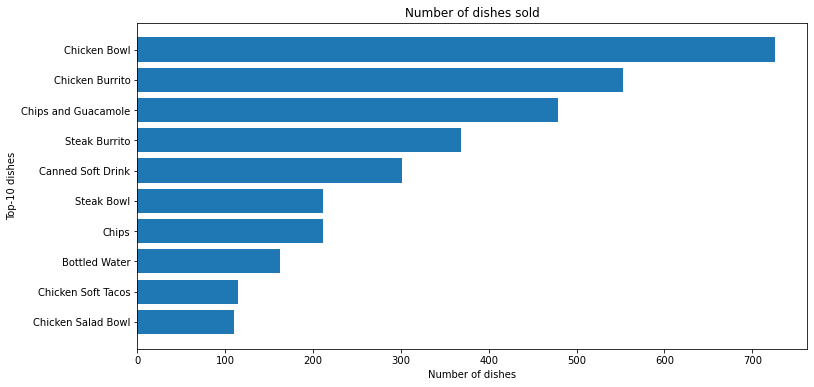

In [248]:
fig, ax = plt.subplots(figsize = (12, 6))
#chipo['item_price'] = chipo['item_price'].apply(lambda x: x.replace('$', '')).astype(float)
price_quantity = chipo[['item_name', 'quantity']].groupby(by = ['item_name']).count().sort_values(by = 'quantity').tail(10)
price_quantity = price_quantity.reset_index()

ax.barh(price_quantity['item_name'], price_quantity['quantity'])
ax.set(
    xlabel = 'Number of dishes',
    ylabel = 'Top-10 dishes',
    title = 'Number of dishes sold'
)


plt.show()

### Шаг 6. Создайте скаттерплот количества блюд / цены заказа
#### не забудьте подписать оси и добавить название графика

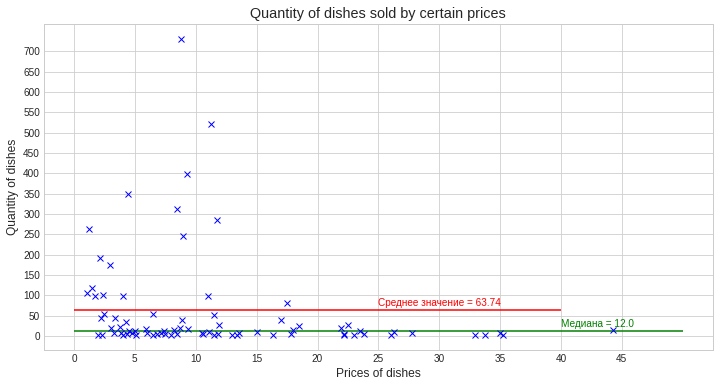

In [327]:
plt.style.use('seaborn-whitegrid')

fig, ax = plt.subplots(figsize = (12, 6))

price_quantity = chipo[['item_price', 'quantity']].groupby(by = 'item_price').sum()
price_quantity = price_quantity.sort_values(by = 'item_price')

ax.plot(price_quantity, 'xb')
ax.set(
    xlabel = 'Prices of dishes',
    ylabel = 'Quantity of dishes',
    title = 'Quantity of dishes sold by certain prices'
)

ax.hlines(price_quantity.mean(), 0, 40, color='r')
ax.text(25, price_quantity.mean() + 10, f'Среднее значение = {round(price_quantity.mean()[0], 2)}', c ='r')

ax.hlines(price_quantity.median(), 0, 50, color = 'g')
ax.text(40, price_quantity.median() + 10, f'Медиана = {round(price_quantity.median()[0], 2)}', c ='g')

ax.set_yticks(range(0, 750, 50))
ax.set_xticks(range(0, 50, 5))
plt.show()

### Шаг 7. Бонус. Напишите свой вопрос и график, который на него отвечает.